In [1]:

from fastai.vision.all import *
path = untar_data(URLs.PASCAL_2007)

<div><progress max="1637796771" value="1637801984"></progress> 100.00% [1637801984/1637796771 02:32&lt;00:00]</div>

In [2]:
path.ls()

[Path('/root/.fastai/data/pascal_2007/test.json'), Path('/root/.fastai/data/pascal_2007/train.csv'), Path('/root/.fastai/data/pascal_2007/test'), Path('/root/.fastai/data/pascal_2007/valid.json'), Path('/root/.fastai/data/pascal_2007/train'), Path('/root/.fastai/data/pascal_2007/test.csv'), Path('/root/.fastai/data/pascal_2007/segmentation'), Path('/root/.fastai/data/pascal_2007/train.json')]

In [3]:
df = pd.read_csv(path/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


**Pandas & Dataframes**

In [4]:
# df.iloc[row_selection, column_selection]
df.iloc[:, 0]

0       000005.jpg
1       000007.jpg
2       000009.jpg
3       000012.jpg
4       000016.jpg
           ...    
5006    009954.jpg
5007    009955.jpg
5008    009958.jpg
5009    009959.jpg
5010    009961.jpg
Name: fname, Length: 5011, dtype: object

In [5]:
df.iloc[0,:]

fname       000005.jpg
labels           chair
is_valid          True
Name: 0, dtype: object

In [6]:
df.iloc[0]

fname       000005.jpg
labels           chair
is_valid          True
Name: 0, dtype: object

In [7]:
df['fname']

0       000005.jpg
1       000007.jpg
2       000009.jpg
3       000012.jpg
4       000016.jpg
           ...    
5006    009954.jpg
5007    009955.jpg
5008    009958.jpg
5009    009959.jpg
5010    009961.jpg
Name: fname, Length: 5011, dtype: object

In [8]:
# create new columns
df1 = pd.DataFrame()
df1['a'] = [1, 2, 3, 4]
df1

,a
0,1
1,2
2,3
3,4


In [9]:
df1['b'] = [10, 20, 30, 40]
df1['a'] + df1['b']


0    11
1    22
2    33
3    44
dtype: int64

**Datablocks**  
  
Dear fastai,

Input type = image  
Output type = multiple labels  

Image location = get_x  
Label location = get_y  

Train/valid split = RandomSplitter  

Preprocessing = RandomResizedCrop  

Thanks.  

In [10]:
dblock = DataBlock()

In [11]:
dsets = dblock.datasets(df)

In [12]:
dsets.train[0]

(fname       007016.jpg
 labels          person
 is_valid         False
 Name: 3538, dtype: object,
 fname       007016.jpg
 labels          person
 is_valid         False
 Name: 3538, dtype: object)

In [13]:
dblock = DataBlock(get_x = lambda r: r['fname'], get_y = lambda r: r['labels'])
dsets = dblock.datasets(df)
dsets.train[0]

('001343.jpg', 'tvmonitor chair sofa')

In [14]:
def get_x(r): return r['fname']
def get_y(r): return r['labels']
dblock = DataBlock(get_x = get_x, get_y = get_y)
dsets = dblock.datasets(df)
dsets.train[0]


('005081.jpg', 'horse dog person')

In [15]:
def get_x(r): return path/'train'/r['fname']
def get_y(r): return r['labels'].split(' ')
dblock = DataBlock(get_x = get_x, get_y = get_y)
dsets = dblock.datasets(df)
dsets.train[0]
dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                   get_x = get_x, get_y = get_y)
dsets = dblock.datasets(df)
dsets.train[0]

(PILImage mode=RGB size=500x375,
 TensorMultiCategory([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
                      0., 0., 0., 0., 0.]))

In [16]:
dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                   get_x = get_x, get_y = get_y)
dsets = dblock.datasets(df)
dsets.train[0]


(PILImage mode=RGB size=500x333,
 TensorMultiCategory([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.,
                      0., 0., 0., 0., 0.]))

In [17]:
idxs = torch.where(dsets.train[0][1]==1.)[0]
dsets.train.vocab[idxs]

['horse', 'person']

In [18]:
def splitter(df):
    train = df.index[~df['is_valid']].tolist()
    valid = df.index[df['is_valid']].tolist()
    return train,valid

dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                   splitter=splitter,
                   get_x=get_x, 
                   get_y=get_y)

dsets = dblock.datasets(df)
dsets.train[0]

(PILImage mode=RGB size=500x333,
 TensorMultiCategory([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
                      0., 0., 0., 0., 0.]))

In [19]:
dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                   splitter=splitter,
                   get_x=get_x, 
                   get_y=get_y,
                   item_tfms = RandomResizedCrop(128, min_scale=0.35))
dls = dblock.dataloaders(df)

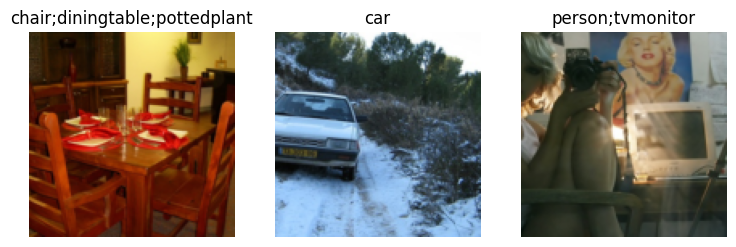

In [20]:

dls.show_batch(nrows=1, ncols=3)

Binary Cross Entropy

In [22]:
learn = vision_learner(dls, resnet18)

In [26]:
# x.device
# next(learn.model.parameters()).device
learn.model.cuda()
x,y = dls.train.one_batch()
activs = learn.model(x)
activs.shape

torch.Size([64, 20])

In [27]:
activs[0]

TensorImage([-0.7998,  4.2510,  0.2564, -1.8711, -3.7611, -6.0142,  0.3648,
             -5.3218, -0.5120,  2.1745,  2.5464,  2.5077,  1.7302, -1.5485,
             -2.6613,  5.1647,  0.0390, -1.2378,  1.1783, -0.0258],
            device='cuda:0', grad_fn=<AliasBackward0>)

In [ ]:
# def binary_cross_entropy(inputs, targets):
#     inputs = inputs.sigmoid()
#     return -torch.where(targets==1, inputs, 1-inputs).log().mean()

**Binary Cross Entropy measures how far the model's predicted probabilities are from the true labels, giving a large penalty for confident wrong predictions and a small penalty for confident correct predictions.**

In [31]:

# type(activs)
# type(y)
loss_func = nn.BCEWithLogitsLoss()

loss = loss_func(
    activs.as_subclass(torch.Tensor),
    y.as_subclass(torch.Tensor).float()
)

loss

tensor(1.0883, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [32]:
def say_hello(name, say_what="Hello"): return f"{say_what} {name}."
say_hello('Jeremy'),say_hello('Jeremy', 'Ahoy!')

('Hello Jeremy.', 'Ahoy! Jeremy.')

In [33]:
f = partial(say_hello, say_what="Bonjour")
f("Jeremy"),f("Sylvain")

('Bonjour Jeremy.', 'Bonjour Sylvain.')

In [34]:
learn = vision_learner(dls, resnet50, metrics=partial(accuracy_multi, thresh=0.2))
learn.fine_tune(3, base_lr=3e-3, freeze_epochs=4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 233MB/s]


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.965132,0.691849,0.236175,00:13
1,0.827570,0.533014,0.295717,00:13
2,0.602803,0.196706,0.817849,00:13
3,0.356120,0.116072,0.945896,00:12


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.132437,0.102061,0.952908,00:15
1,0.115755,0.097861,0.956713,00:16
2,0.099370,0.094037,0.957888,00:16


In [35]:
learn.metrics = partial(accuracy_multi, thresh=0.1)
learn.validate()

[0.0940365344285965, 0.9393425583839417]

In [36]:
learn.metrics = partial(accuracy_multi, thresh=0.99)
learn.validate()

[0.0940365344285965, 0.9445818066596985]

In [37]:

preds,targs = learn.get_preds()

In [38]:

accuracy_multi(preds, targs, thresh=0.9, sigmoid=False)

TensorBase(0.9587)

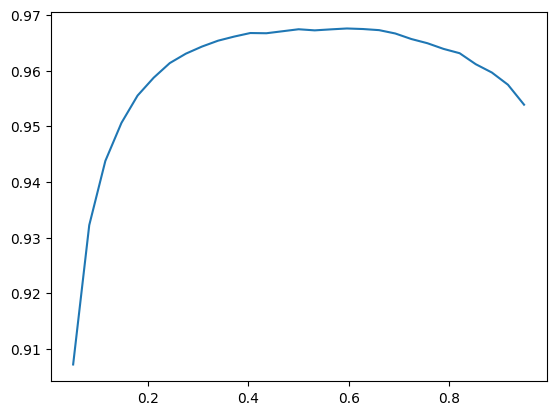

In [39]:

xs = torch.linspace(0.05,0.95,29)
accs = [accuracy_multi(preds, targs, thresh=i, sigmoid=False) for i in xs]
plt.plot(xs,accs);